# Thesis Visualizations — Comparative Analysis

> Publication-ready comparative visualizations for Master's thesis:
> *"Dual Cryptographic Threats of Shor's and Grover's Algorithms"*

This notebook is **entirely decoupled from circuit execution**. It loads
pre-computed data from `results/shor/` and `results/grover/`, generates all
comparative thesis plots, and saves them to `results/thesis_plots/`.

**Figures generated:**
1. Noise Sensitivity Comparison (success prob vs 2q-depth)
2. TVD Hardware vs Noisy Simulation
3. Degradation Bar Comparison at matched depths
4. Distribution Fingerprints (ideal vs hardware)
5. Entropy Efficiency Heatmap
6. DD Effectiveness Delta Plot
7. Fidelity Decay with Exponential Fit


In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit


## Configuration & Data Loading

In [3]:
# ─── Paths (standardized output structure) ───
OUTPUT_DIR = os.path.join('results', 'thesis_plots')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SHOR_CSV = os.path.join('results', 'shor', 'shor_results.csv')
GROVER_CSV = os.path.join('results', 'grover', 'grover_results.csv')
SHOR_JSON = os.path.join('results', 'shor', 'shor_results.json')
GROVER_JSON = os.path.join('results', 'grover', 'grover_results.json')

# Publication styling
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Color palette
C_SHOR_HW = '#1f77b4'
C_SHOR_NOISY = '#aec7e8'
C_GROVER_HW = '#d62728'
C_GROVER_NOISY = '#ff9896'
C_IDEAL = '#2ca02c'


In [4]:
# ─── Load CSV data ───
print('Loading CSVs...')
shor = pd.read_csv(SHOR_CSV)
grover = pd.read_csv(GROVER_CSV)

# Normalize for unified processing
shor['algorithm'] = 'Shor'
shor['circuit_label'] = shor['num_control'].apply(lambda x: f'{x}-ctrl ({x+4} qubits)')
shor['circuit_size'] = shor['num_control']

grover['algorithm'] = 'Grover'
grover['circuit_label'] = grover['num_qubits'].apply(lambda x: f'{x}-qubit (N={2**x})')
grover['circuit_size'] = grover['num_qubits']

# Compute degradation
shor['hw_degradation'] = shor['ideal_success_prob'] - shor['hw_success_prob']
shor['noisy_degradation'] = shor['ideal_success_prob'] - shor['noisy_success_prob']
grover['hw_degradation'] = grover['ideal_success_prob'] - grover['hw_success_prob']
grover['noisy_degradation'] = grover['ideal_success_prob'] - grover['noisy_success_prob']

print(f'  Shor:   {len(shor)} rows, circuit sizes: {sorted(shor["circuit_size"].unique())}')
print(f'  Grover: {len(grover)} rows, circuit sizes: {sorted(grover["circuit_size"].unique())}')


Loading CSVs...
  Shor:   227 rows, circuit sizes: [np.int64(4), np.int64(6)]
  Grover: 48 rows, circuit sizes: [np.int64(2), np.int64(3), np.int64(4)]


In [5]:
# ─── Load JSON distributions ───
print('Loading JSON distributions...')
with open(SHOR_JSON) as f:
    shor_json = json.load(f)
with open(GROVER_JSON) as f:
    grover_json = json.load(f)

shor_dists = shor_json['distributions']
grover_dists = grover_json['distributions']
shor_runs_meta = {r['run_id']: r for r in shor_json['runs']}
grover_runs_meta = {r['run_id']: r for r in grover_json['runs']}

print(f'  Shor distributions: {len(shor_dists)}')
print(f'  Grover distributions: {len(grover_dists)}')


Loading JSON distributions...
  Shor distributions: 227
  Grover distributions: 48


## Information-Theoretic Metrics

Compute Shannon entropy, KL-divergence, entropy efficiency, and participation ratio from the full probability distributions.

In [6]:
def shannon_entropy(dist, num_bits):
    probs = np.array([dist.get(format(i, f'0{num_bits}b'), 0.0)
                      for i in range(2**num_bits)], dtype=np.float64)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def kl_divergence(p_ideal, p_hw, num_bits):
    eps = 1e-12
    total = 0.0
    for i in range(2**num_bits):
        bs = format(i, f'0{num_bits}b')
        pi = p_ideal.get(bs, 0.0)
        qi = p_hw.get(bs, 0.0)
        if pi > 0:
            total += pi * np.log2(pi / max(qi, eps))
    return total

def participation_ratio(dist, num_bits):
    probs = np.array([dist.get(format(i, f'0{num_bits}b'), 0.0)
                      for i in range(2**num_bits)], dtype=np.float64)
    ipr = np.sum(probs**2)
    return 1.0 / ipr if ipr > 0 else 0.0

def compute_info_metrics(dists_dict, runs_meta, size_key, num_bits_fn):
    rows = []
    for run_id, tiers in dists_dict.items():
        meta = runs_meta.get(run_id, {})
        nb = num_bits_fn(meta)
        h_max = float(nb)

        ideal = tiers.get('ideal', {})
        noisy = tiers.get('noisy', {})
        hw = tiers.get('hardware', {})

        h_ideal = shannon_entropy(ideal, nb)
        h_noisy = shannon_entropy(noisy, nb)
        h_hw = shannon_entropy(hw, nb)

        denom = h_max - h_ideal
        eta_noisy = 1.0 - (h_noisy - h_ideal) / denom if denom > 0 else 1.0
        eta_hw = 1.0 - (h_hw - h_ideal) / denom if denom > 0 else 1.0

        rows.append({
            'run_id': run_id,
            size_key: meta.get(size_key),
            'opt_level': meta.get('opt_level'),
            'dd_enable': meta.get('dd_enable'),
            'resilience_level': meta.get('resilience_level'),
            'depth_2q': meta.get('depth_2q'),
            'count_2q': meta.get('count_2q'),
            'h_ideal': round(h_ideal, 4),
            'h_noisy': round(h_noisy, 4),
            'h_hw': round(h_hw, 4),
            'h_max': h_max,
            'eta_hw': round(eta_hw, 4),
            'eta_noisy': round(eta_noisy, 4),
            'kl_ideal_hw': round(kl_divergence(ideal, hw, nb), 4),
            'kl_ideal_noisy': round(kl_divergence(ideal, noisy, nb), 4),
            'pr_ideal': round(participation_ratio(ideal, nb), 2),
            'pr_noisy': round(participation_ratio(noisy, nb), 2),
            'pr_hw': round(participation_ratio(hw, nb), 2),
        })
    return pd.DataFrame(rows)


In [7]:
print('Computing information-theoretic metrics...')
shor_info = compute_info_metrics(
    shor_dists, shor_runs_meta, 'num_control',
    lambda m: int(m.get('num_control', 4))
)
grover_info = compute_info_metrics(
    grover_dists, grover_runs_meta, 'num_qubits',
    lambda m: int(m.get('num_qubits', 2))
)

print('\n  Shor entropy efficiency (eta_hw) by config:')
for nc in sorted(shor_info['num_control'].unique()):
    sub = shor_info[shor_info['num_control'] == nc]
    print(f'    {nc}-ctrl: eta_hw = {sub["eta_hw"].mean():.3f} +/- {sub["eta_hw"].std():.3f}'
          f'  KL = {sub["kl_ideal_hw"].mean():.3f}  PR_hw = {sub["pr_hw"].mean():.1f}')

print('\n  Grover entropy efficiency (eta_hw) by config:')
for nq in sorted(grover_info['num_qubits'].unique()):
    sub = grover_info[grover_info['num_qubits'] == nq]
    print(f'    {nq}-qubit: eta_hw = {sub["eta_hw"].mean():.3f} +/- {sub["eta_hw"].std():.3f}'
          f'  KL = {sub["kl_ideal_hw"].mean():.3f}  PR_hw = {sub["pr_hw"].mean():.1f}')


Computing information-theoretic metrics...

  Shor entropy efficiency (eta_hw) by config:
    4-ctrl: eta_hw = 0.414 +/- 0.106  KL = 0.467  PR_hw = 7.0
    6-ctrl: eta_hw = 0.290 +/- 0.108  KL = 1.269  PR_hw = 18.7

  Grover entropy efficiency (eta_hw) by config:
    2-qubit: eta_hw = 0.809 +/- 0.069  KL = 0.103  PR_hw = 1.1
    3-qubit: eta_hw = 0.600 +/- 0.056  KL = 0.196  PR_hw = 1.7
    4-qubit: eta_hw = 0.275 +/- 0.079  KL = 0.859  PR_hw = 4.3


---
## Fig. 1: Noise Sensitivity Comparison

Success probability vs 2q-depth for both algorithms on the same axes.

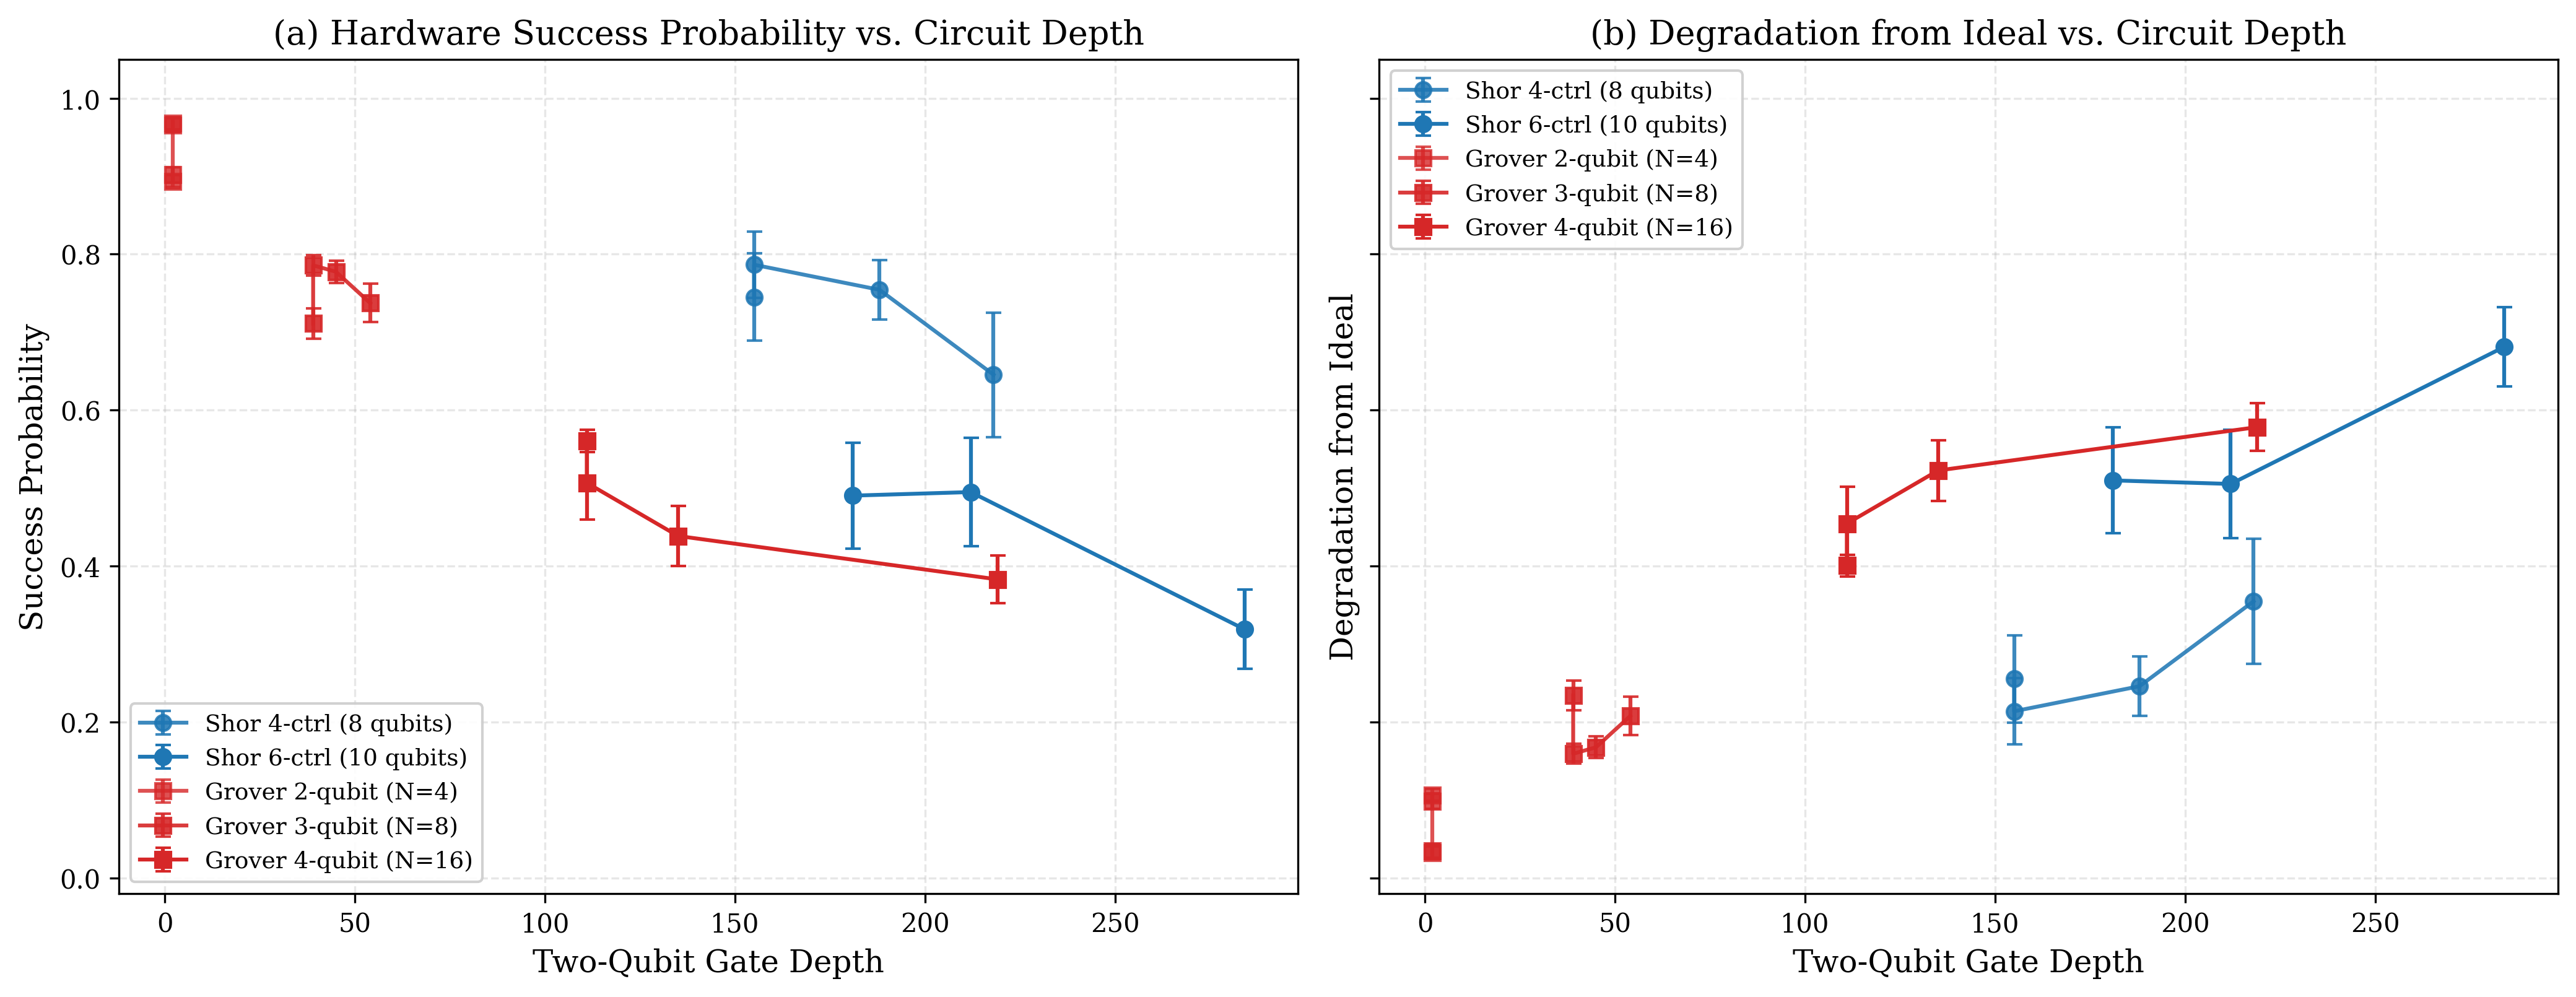

Saved: results/thesis_plots/noise_sensitivity_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

# Panel A: Hardware Success Probability
ax = axes[0]
ax.set_title('(a) Hardware Success Probability vs. Circuit Depth')
for df_a, algo, color, marker in [(shor, 'Shor', C_SHOR_HW, 'o'), (grover, 'Grover', C_GROVER_HW, 's')]:
    for size in sorted(df_a['circuit_size'].unique()):
        sub = df_a[df_a['circuit_size'] == size]
        agg = sub.groupby('opt_level').agg(
            depth_2q=('depth_2q', 'first'),
            hw_mean=('hw_success_prob', 'mean'),
            hw_std=('hw_success_prob', 'std'),
        ).reset_index()
        label_str = sub['circuit_label'].iloc[0]
        ax.errorbar(agg['depth_2q'], agg['hw_mean'], yerr=agg['hw_std'],
                    marker=marker, markersize=6, capsize=3, linewidth=1.5,
                    label=f'{algo} {label_str}',
                    color=color, alpha=0.6 + 0.4 * (size / df_a['circuit_size'].max()))
ax.set_xlabel('Two-Qubit Gate Depth')
ax.set_ylabel('Success Probability')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='lower left', framealpha=0.9, ncol=1)

# Panel B: Degradation
ax = axes[1]
ax.set_title('(b) Degradation from Ideal vs. Circuit Depth')
for df_a, algo, color, marker in [(shor, 'Shor', C_SHOR_HW, 'o'), (grover, 'Grover', C_GROVER_HW, 's')]:
    for size in sorted(df_a['circuit_size'].unique()):
        sub = df_a[df_a['circuit_size'] == size]
        agg = sub.groupby('opt_level').agg(
            depth_2q=('depth_2q', 'first'),
            deg_mean=('hw_degradation', 'mean'),
            deg_std=('hw_degradation', 'std'),
        ).reset_index()
        label_str = sub['circuit_label'].iloc[0]
        ax.errorbar(agg['depth_2q'], agg['deg_mean'], yerr=agg['deg_std'],
                    marker=marker, markersize=6, capsize=3, linewidth=1.5,
                    label=f'{algo} {label_str}',
                    color=color, alpha=0.6 + 0.4 * (size / df_a['circuit_size'].max()))
ax.set_xlabel('Two-Qubit Gate Depth')
ax.set_ylabel('Degradation from Ideal')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='upper left', framealpha=0.9, ncol=1)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'noise_sensitivity_comparison.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 2: TVD — Hardware vs Noisy Simulation

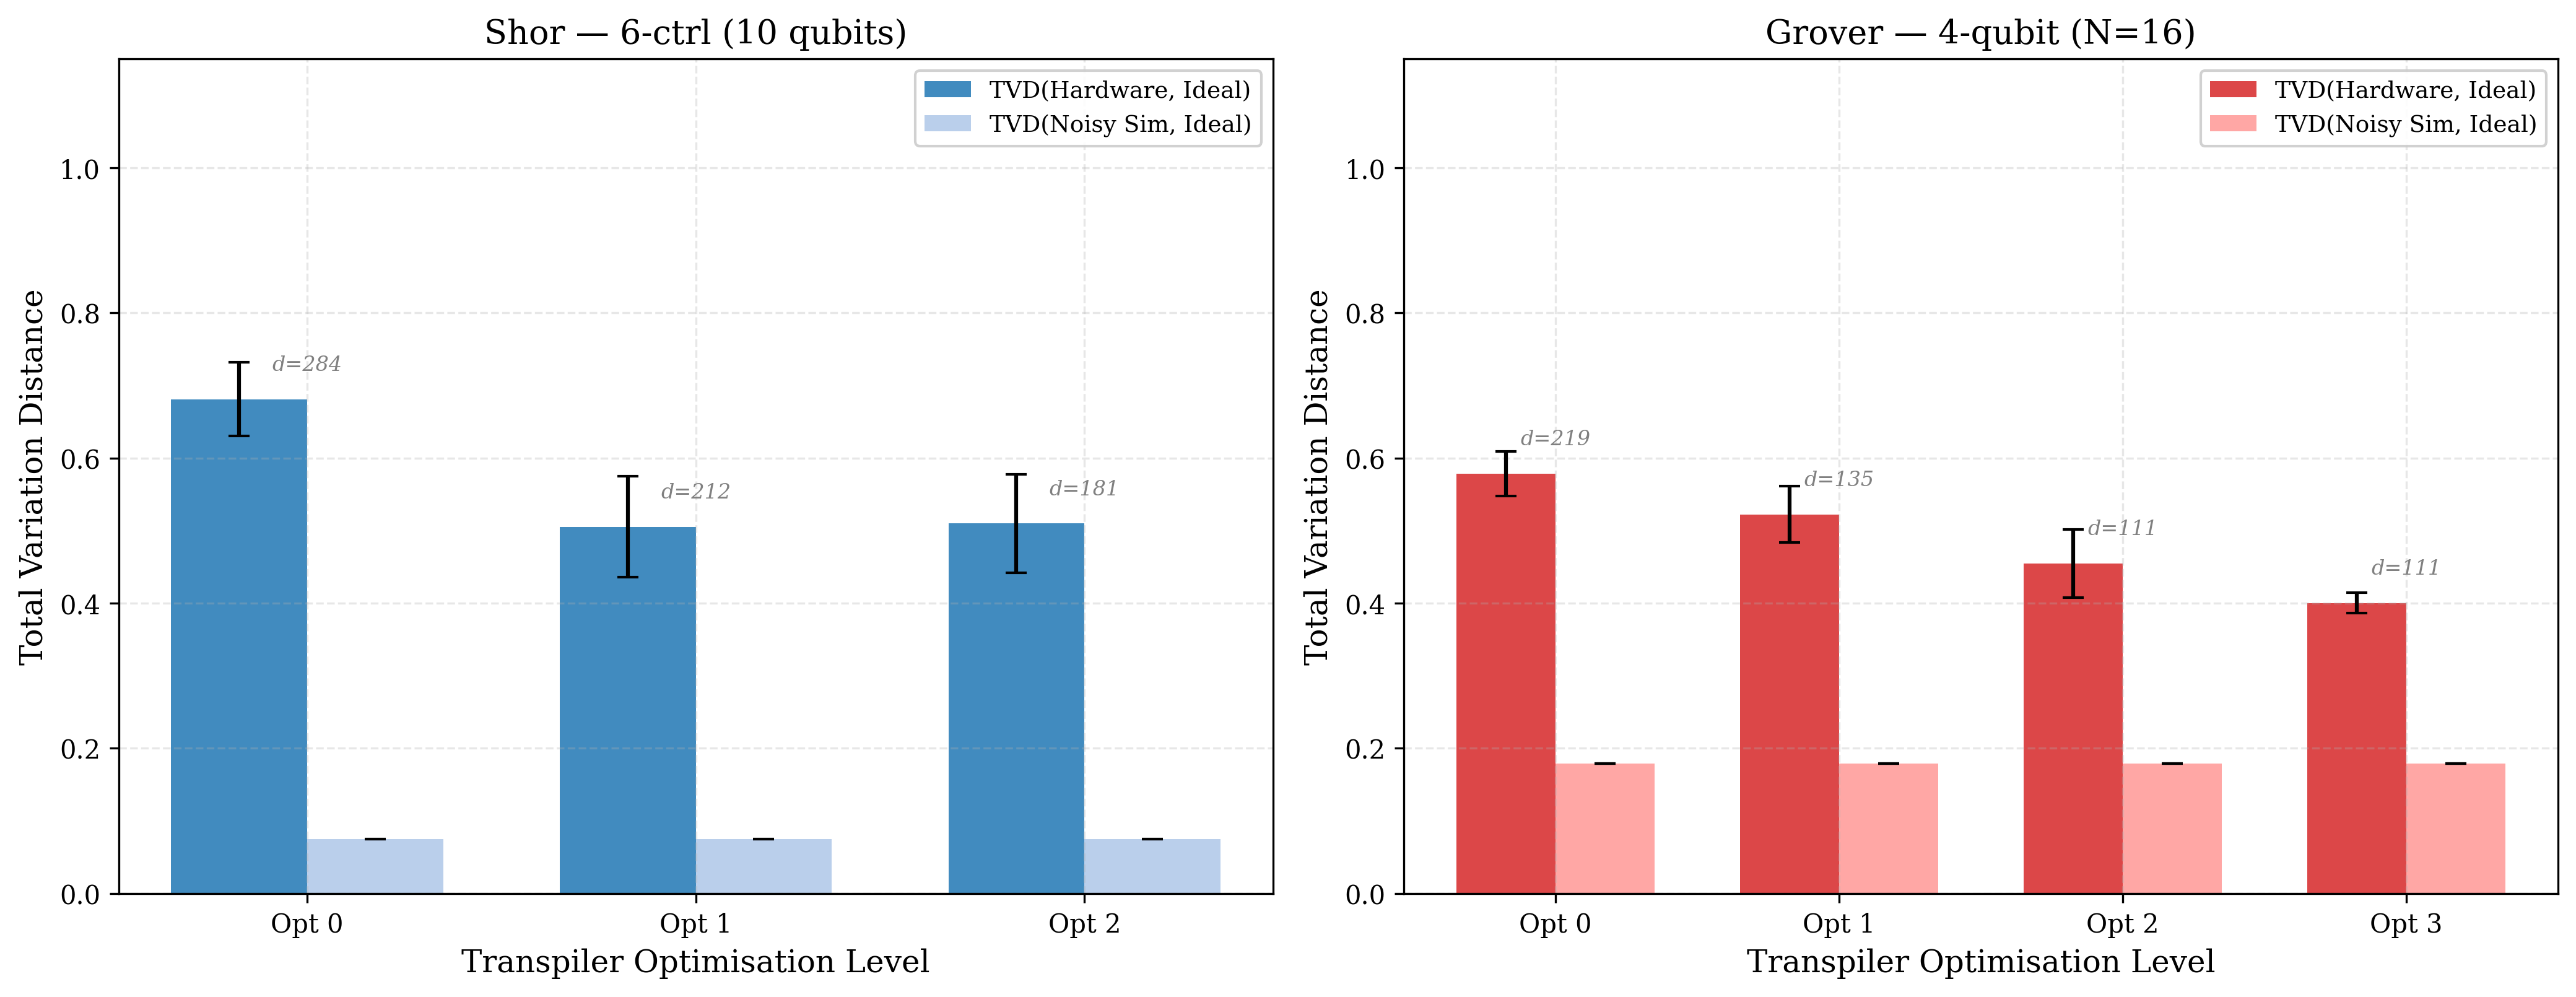

Saved: results/thesis_plots/tvd_hardware_vs_noisy.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

datasets = [
    (shor, 'Shor', shor['circuit_size'].max(), C_SHOR_HW, C_SHOR_NOISY),
    (grover, 'Grover', grover['circuit_size'].max(), C_GROVER_HW, C_GROVER_NOISY),
]

for idx, (df_a, algo, max_size, c_hw, c_noisy) in enumerate(datasets):
    ax = axes[idx]
    sub = df_a[df_a['circuit_size'] == max_size]
    label_str = sub['circuit_label'].iloc[0]

    agg = sub.groupby('opt_level').agg(
        tvd_hw_mean=('tvd_hw_vs_ideal', 'mean'),
        tvd_hw_std=('tvd_hw_vs_ideal', 'std'),
        tvd_noisy_mean=('tvd_noisy_vs_ideal', 'mean'),
        tvd_noisy_std=('tvd_noisy_vs_ideal', 'std'),
        depth_2q=('depth_2q', 'first'),
    ).reset_index()

    x = np.arange(len(agg))
    w = 0.35
    ax.bar(x - w/2, agg['tvd_hw_mean'], w, yerr=agg['tvd_hw_std'], capsize=4,
           color=c_hw, label='TVD(Hardware, Ideal)', alpha=0.85)
    ax.bar(x + w/2, agg['tvd_noisy_mean'], w, yerr=agg['tvd_noisy_std'], capsize=4,
           color=c_noisy, label='TVD(Noisy Sim, Ideal)', alpha=0.85)

    for i, row in agg.iterrows():
        ax.text(i, max(row['tvd_hw_mean'], row['tvd_noisy_mean']) + 0.04,
                f'd={int(row["depth_2q"])}', ha='center', fontsize=8, style='italic', color='gray')

    ax.set_xlabel('Transpiler Optimisation Level')
    ax.set_ylabel('Total Variation Distance')
    ax.set_title(f'{algo} — {label_str}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Opt {int(v)}' for v in agg['opt_level']])
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'tvd_hardware_vs_noisy.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 3: Degradation Bar Comparison

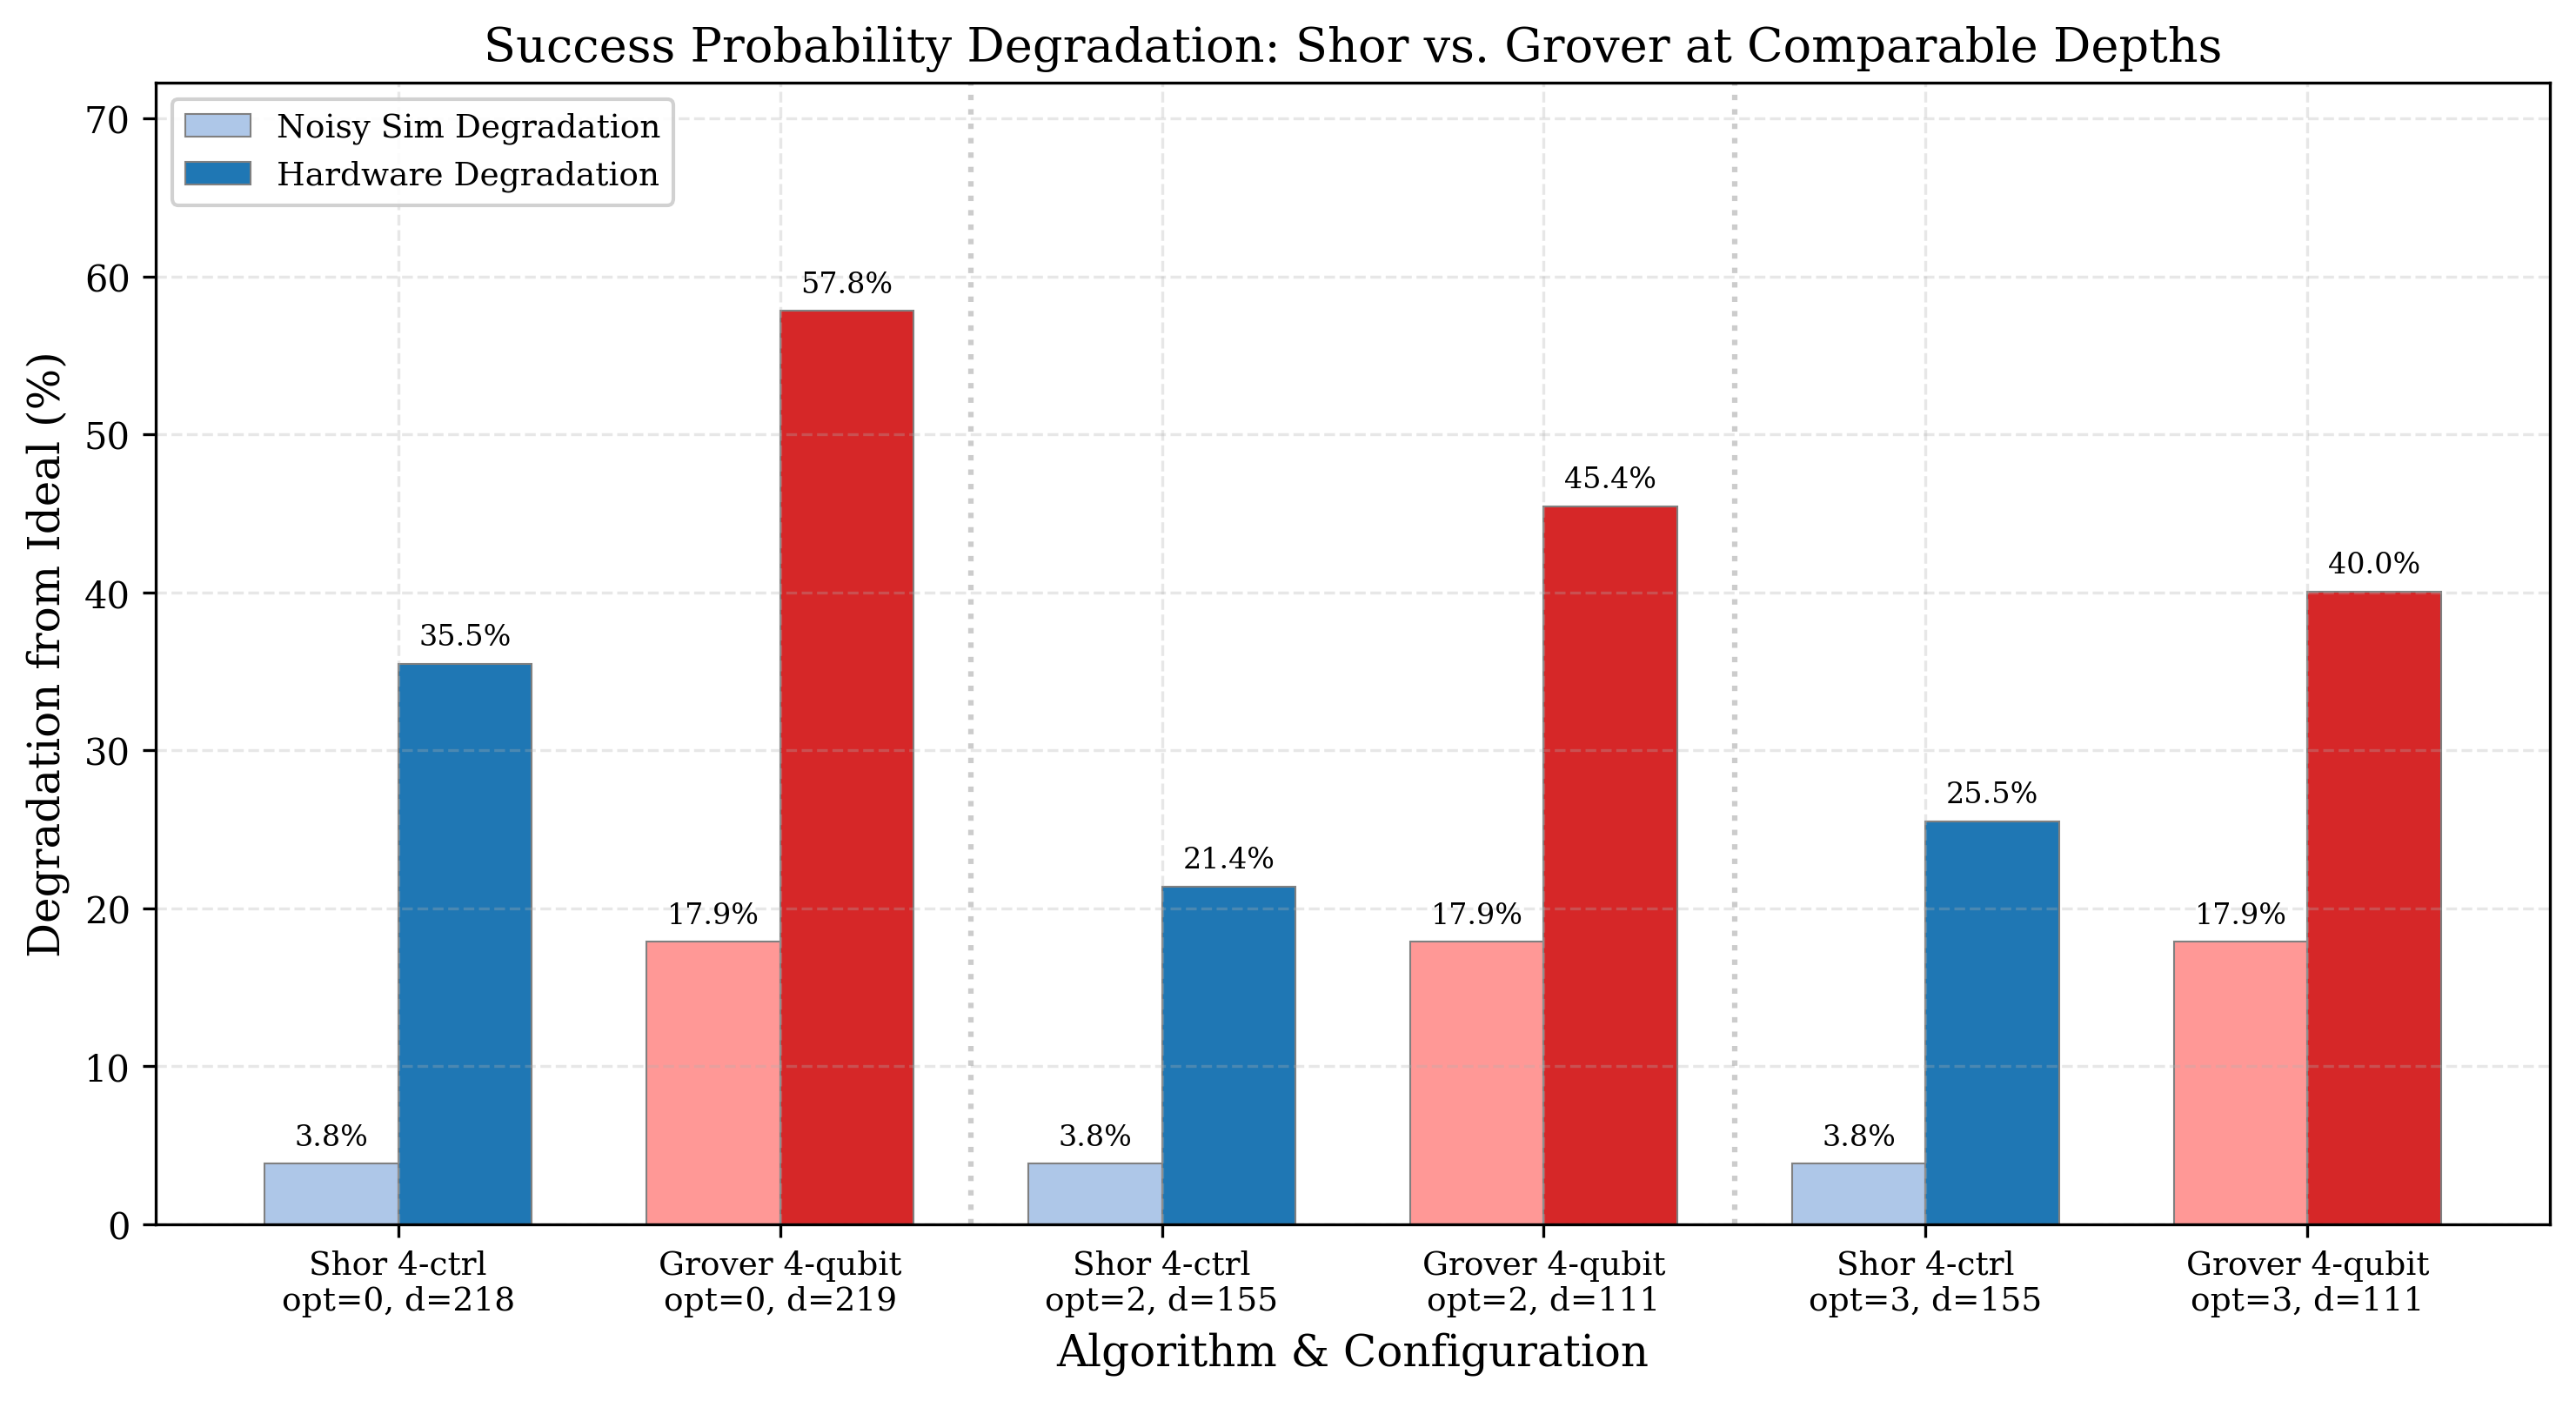

Saved: results/thesis_plots/degradation_bar_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
comparisons = []

for opt, pair_label in [(0, 'opt=0 (~220 depth)'), (2, 'opt=2 (optimised)'), (3, 'opt=3 (aggressive)')]:
    s = shor[(shor['circuit_size'] == 4) & (shor['opt_level'] == opt)]
    g = grover[(grover['circuit_size'] == 4) & (grover['opt_level'] == opt)]
    comparisons.append({'label': f'Shor 4-ctrl\nopt={opt}, d={int(s["depth_2q"].iloc[0])}',
                        'noisy_deg': s['noisy_degradation'].mean() * 100,
                        'hw_deg': s['hw_degradation'].mean() * 100, 'algo': 'Shor'})
    comparisons.append({'label': f'Grover 4-qubit\nopt={opt}, d={int(g["depth_2q"].iloc[0])}',
                        'noisy_deg': g['noisy_degradation'].mean() * 100,
                        'hw_deg': g['hw_degradation'].mean() * 100, 'algo': 'Grover'})

labels = [c['label'] for c in comparisons]
noisy_vals = [c['noisy_deg'] for c in comparisons]
hw_vals = [c['hw_deg'] for c in comparisons]
bar_colors_hw = [C_SHOR_HW if c['algo'] == 'Shor' else C_GROVER_HW for c in comparisons]
bar_colors_noisy = [C_SHOR_NOISY if c['algo'] == 'Shor' else C_GROVER_NOISY for c in comparisons]

x = np.arange(len(labels))
w = 0.35
bars_n = ax.bar(x - w/2, noisy_vals, w, color=bar_colors_noisy,
                label='Noisy Sim Degradation', edgecolor='gray', linewidth=0.5)
bars_h = ax.bar(x + w/2, hw_vals, w, color=bar_colors_hw,
                label='Hardware Degradation', edgecolor='gray', linewidth=0.5)

for bar in bars_n:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)
for bar in bars_h:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)

for sep in [1.5, 3.5]:
    ax.axvline(x=sep, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel('Algorithm & Configuration')
ax.set_ylabel('Degradation from Ideal (%)')
ax.set_title('Success Probability Degradation: Shor vs. Grover at Comparable Depths')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(0, max(hw_vals) * 1.25)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'degradation_bar_comparison.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 4: Distribution Fingerprints

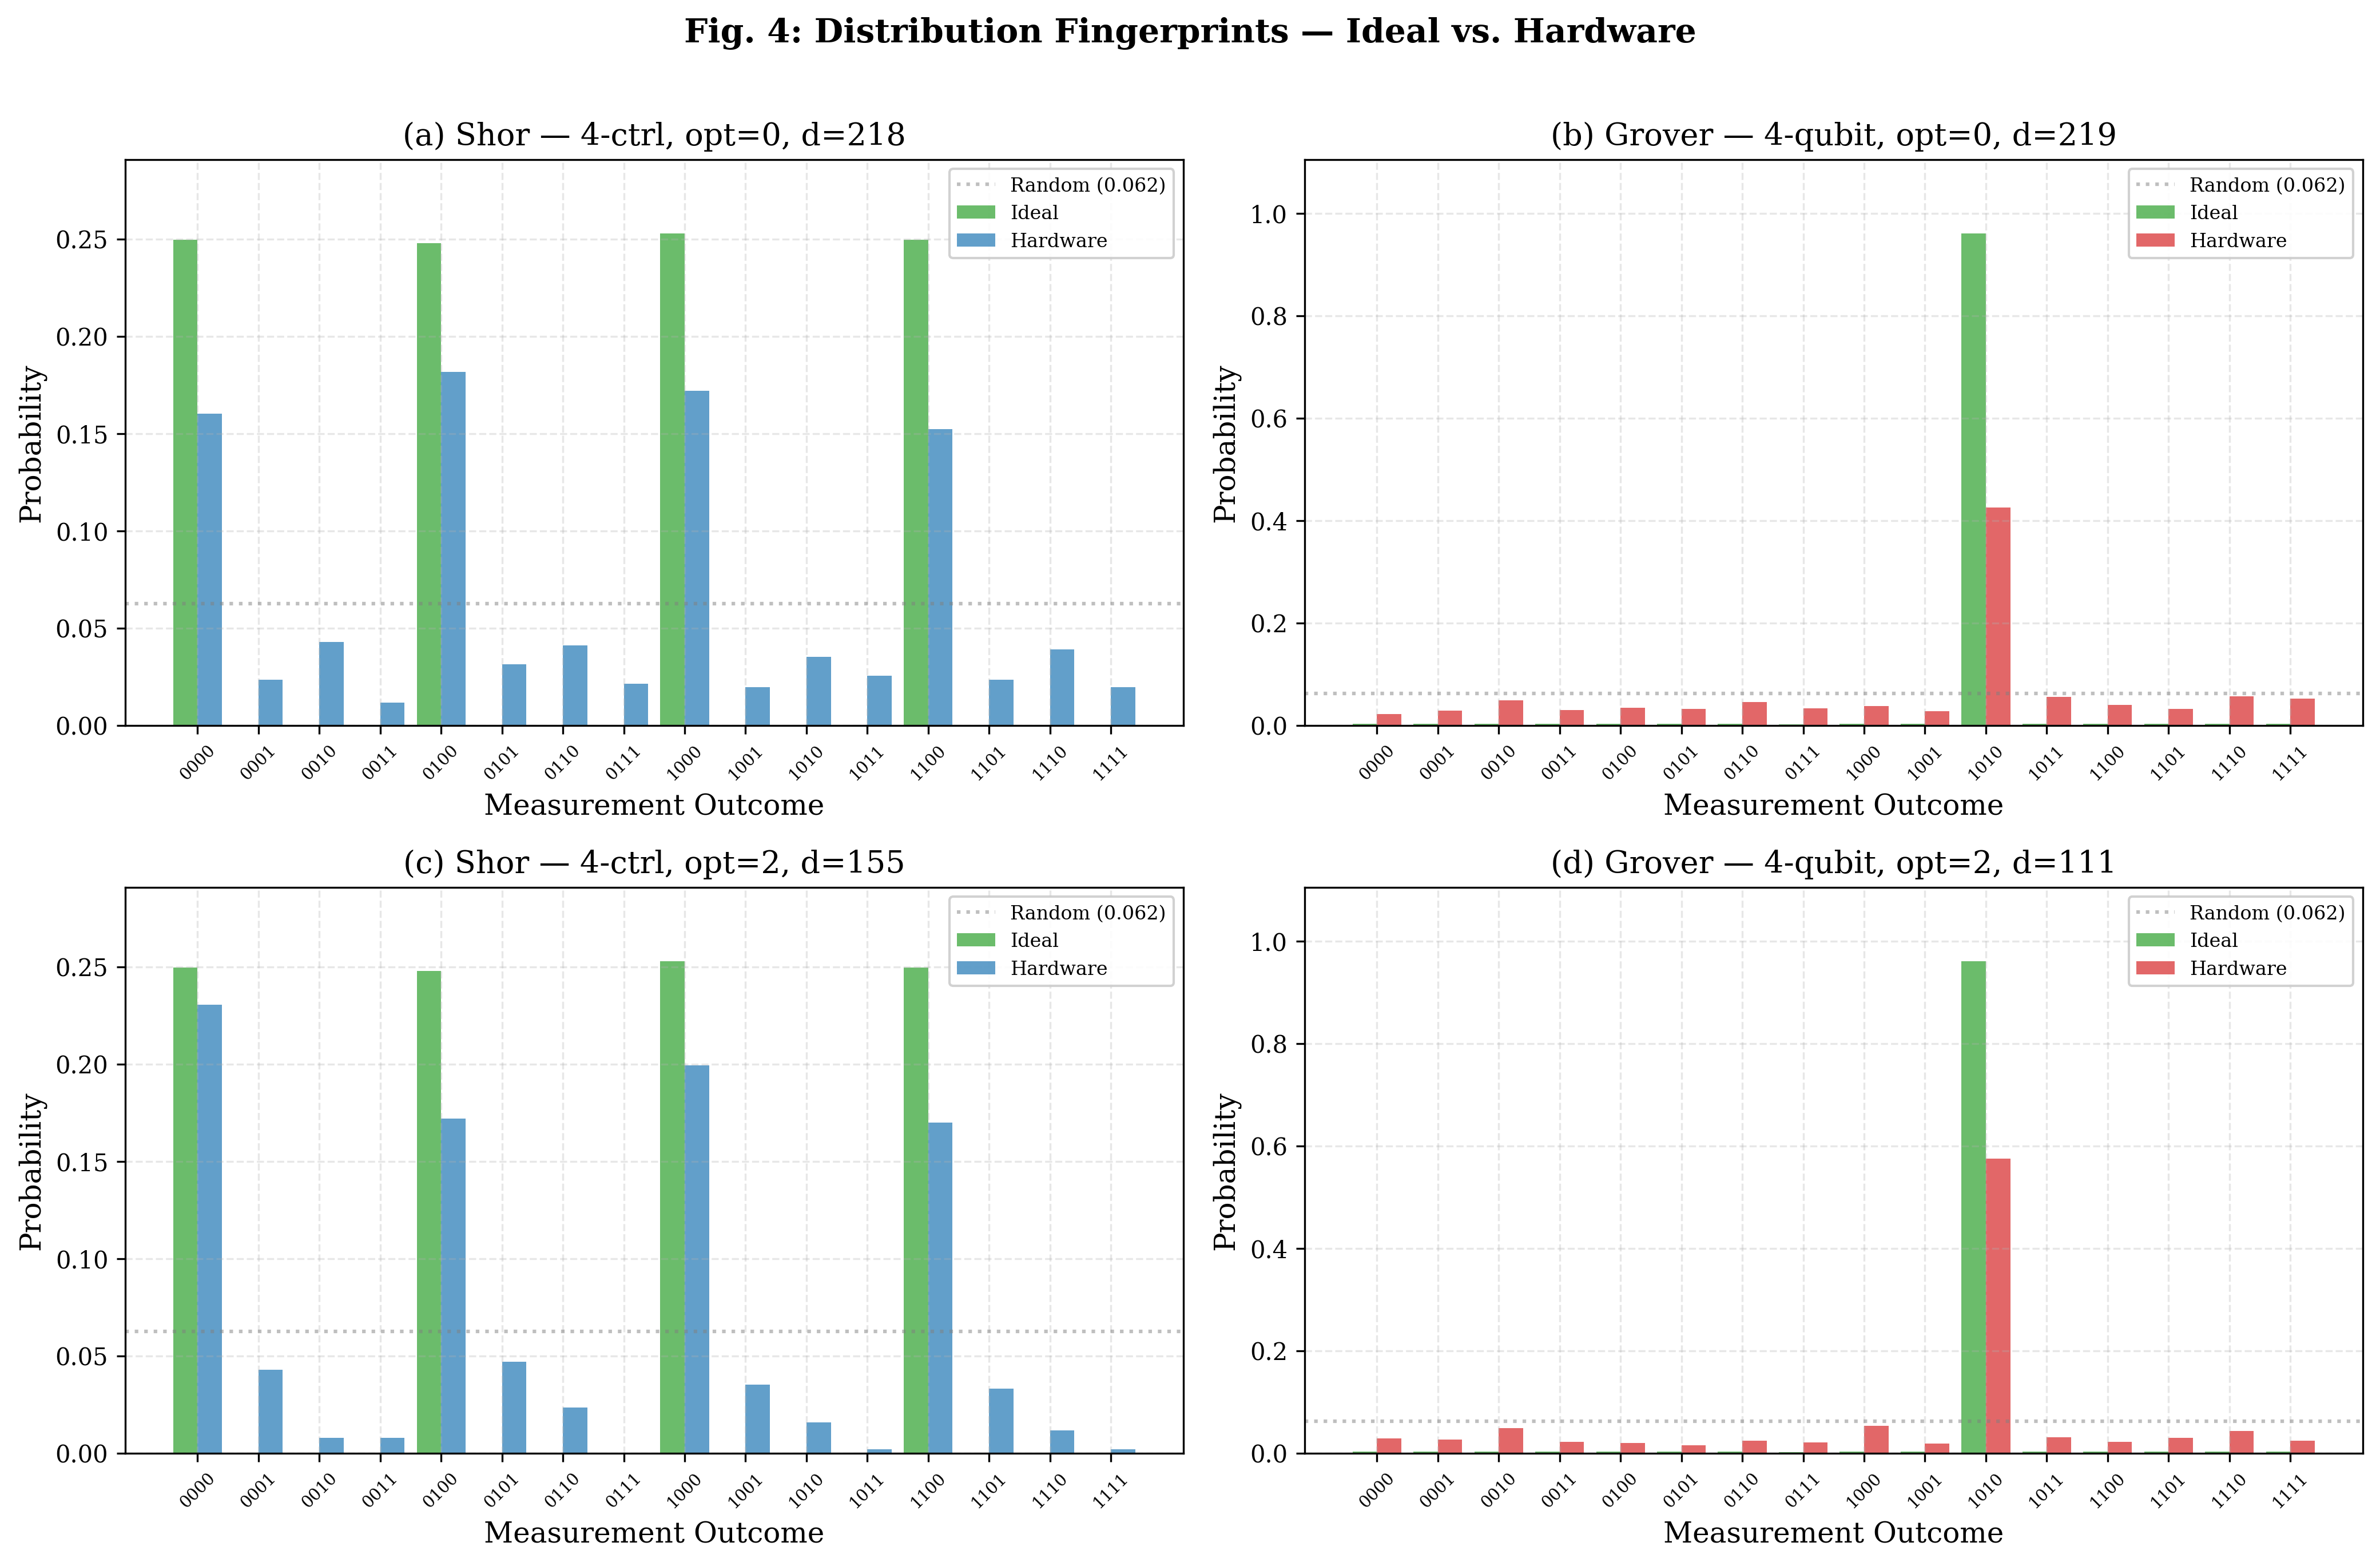

Saved: results/thesis_plots/distribution_fingerprints.png


In [11]:
configs = [
    ('Shor', shor_dists, shor_runs_meta, 'num_control', 4, 0, 4, '4-ctrl, opt=0, d=218'),
    ('Grover', grover_dists, grover_runs_meta, 'num_qubits', 4, 0, 4, '4-qubit, opt=0, d=219'),
    ('Shor', shor_dists, shor_runs_meta, 'num_control', 4, 2, 4, '4-ctrl, opt=2, d=155'),
    ('Grover', grover_dists, grover_runs_meta, 'num_qubits', 4, 2, 4, '4-qubit, opt=2, d=111'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for idx, (algo, dists, meta, sk, sv, opt, nb, title) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]

    run_id = None
    for rid, m in meta.items():
        if (m.get(sk) == sv and m.get('opt_level') == opt
                and m.get('dd_enable') is True and m.get('resilience_level') == 0):
            run_id = rid
            break
    if run_id is None:
        for rid, m in meta.items():
            if m.get(sk) == sv and m.get('opt_level') == opt:
                run_id = rid
                break

    ideal = dists[run_id]['ideal']
    hw = dists[run_id]['hardware']

    states = [format(i, f'0{nb}b') for i in range(2**nb)]
    ideal_probs = [ideal.get(s, 0.0) for s in states]
    hw_probs = [hw.get(s, 0.0) for s in states]

    x = np.arange(len(states))
    w = 0.4
    ax.bar(x - w/2, ideal_probs, w, color=C_IDEAL, alpha=0.7, label='Ideal')
    color = C_SHOR_HW if algo == 'Shor' else C_GROVER_HW
    ax.bar(x + w/2, hw_probs, w, color=color, alpha=0.7, label='Hardware')
    ax.axhline(y=1.0/2**nb, color='gray', linestyle=':', alpha=0.5,
               label=f'Random ({1.0/2**nb:.3f})')
    ax.set_xlabel('Measurement Outcome')
    ax.set_ylabel('Probability')
    panel_label = chr(97 + idx)
    ax.set_title(f'({panel_label}) {algo} — {title}')
    if len(states) <= 16:
        ax.set_xticks(x)
        ax.set_xticklabels(states, rotation=45, fontsize=7)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_ylim(0, max(max(ideal_probs), max(hw_probs)) * 1.15)

plt.suptitle('Fig. 4: Distribution Fingerprints — Ideal vs. Hardware',
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'distribution_fingerprints.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 5: Entropy Efficiency Heatmap

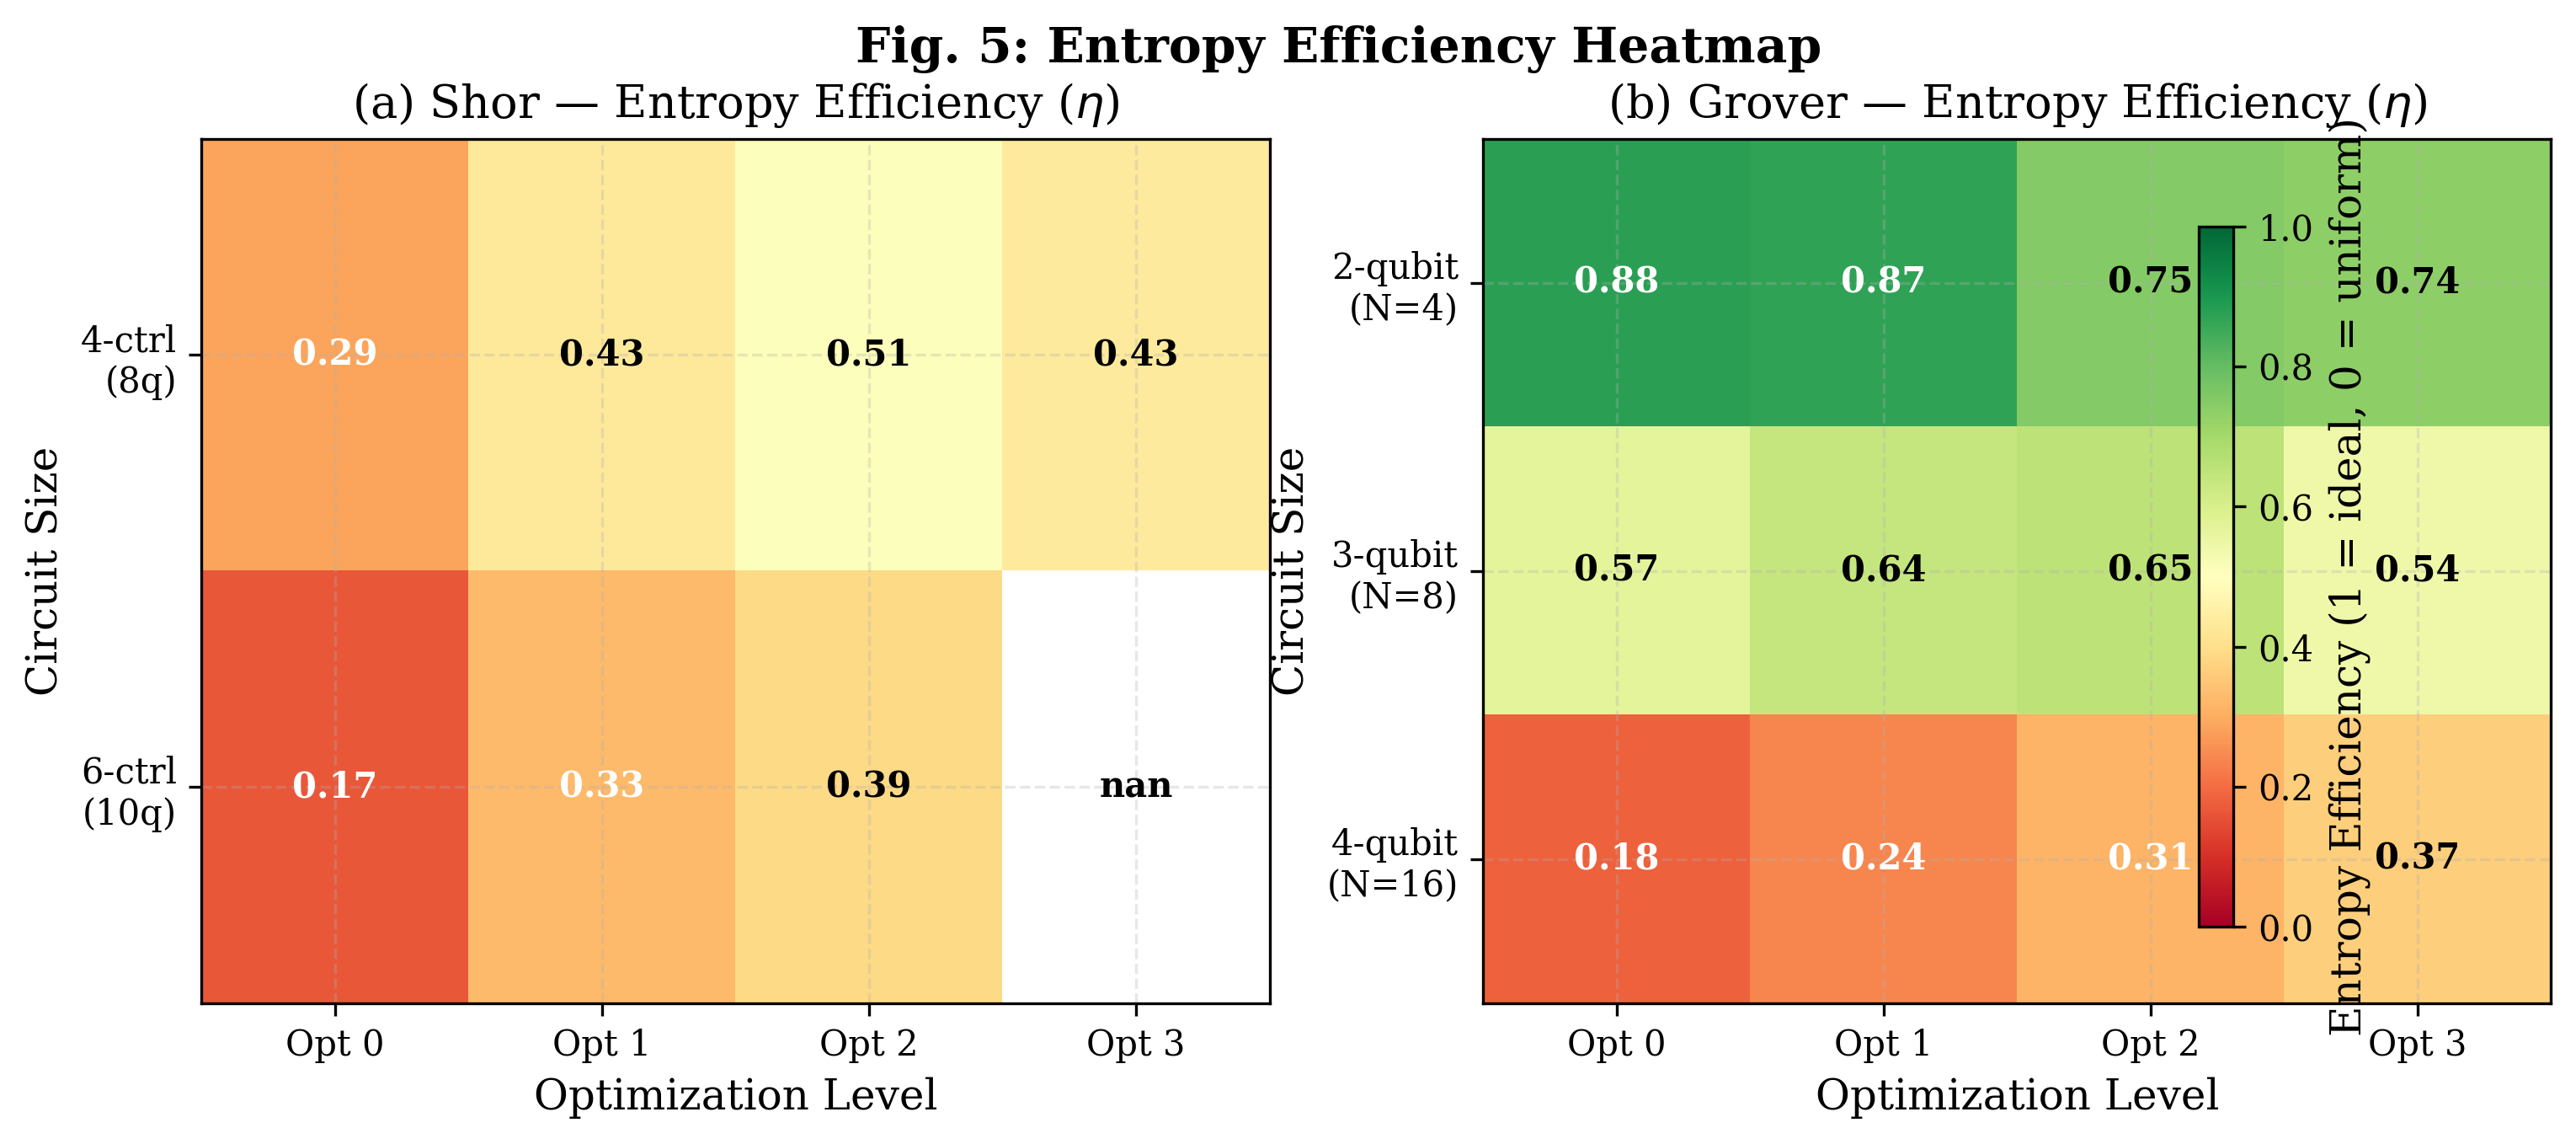

Saved: results/thesis_plots/entropy_heatmap.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for idx, (info_df, title, size_key, size_labels) in enumerate([
    (shor_info, 'Shor', 'num_control',
     {4: '4-ctrl\n(8q)', 6: '6-ctrl\n(10q)', 8: '8-ctrl\n(12q)'}),
    (grover_info, 'Grover', 'num_qubits',
     {2: '2-qubit\n(N=4)', 3: '3-qubit\n(N=8)', 4: '4-qubit\n(N=16)'}),
]):
    ax = axes[idx]
    sizes = sorted(info_df[size_key].unique())
    opts = sorted(info_df['opt_level'].unique())

    matrix = np.zeros((len(sizes), len(opts)))
    for si, sz in enumerate(sizes):
        for oi, opt in enumerate(opts):
            sub = info_df[(info_df[size_key] == sz) & (info_df['opt_level'] == opt)]
            matrix[si, oi] = sub['eta_hw'].mean()

    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    for si in range(len(sizes)):
        for oi in range(len(opts)):
            val = matrix[si, oi]
            color = 'white' if val < 0.35 or val > 0.85 else 'black'
            ax.text(oi, si, f'{val:.2f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=color)

    ax.set_xticks(range(len(opts)))
    ax.set_xticklabels([f'Opt {o}' for o in opts])
    ax.set_yticks(range(len(sizes)))
    ax.set_yticklabels([size_labels.get(s, str(s)) for s in sizes])
    ax.set_xlabel('Optimization Level')
    ax.set_ylabel('Circuit Size')
    panel_label = chr(97 + idx)
    ax.set_title(f'({panel_label}) {title} — Entropy Efficiency ($\\eta$)')

fig.colorbar(im, ax=axes, shrink=0.8, label='Entropy Efficiency (1 = ideal, 0 = uniform)')
plt.suptitle('Fig. 5: Entropy Efficiency Heatmap', fontsize=14, weight='bold')
fig.subplots_adjust(top=0.88, bottom=0.12)
path = os.path.join(OUTPUT_DIR, 'entropy_heatmap.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 6: DD Effectiveness

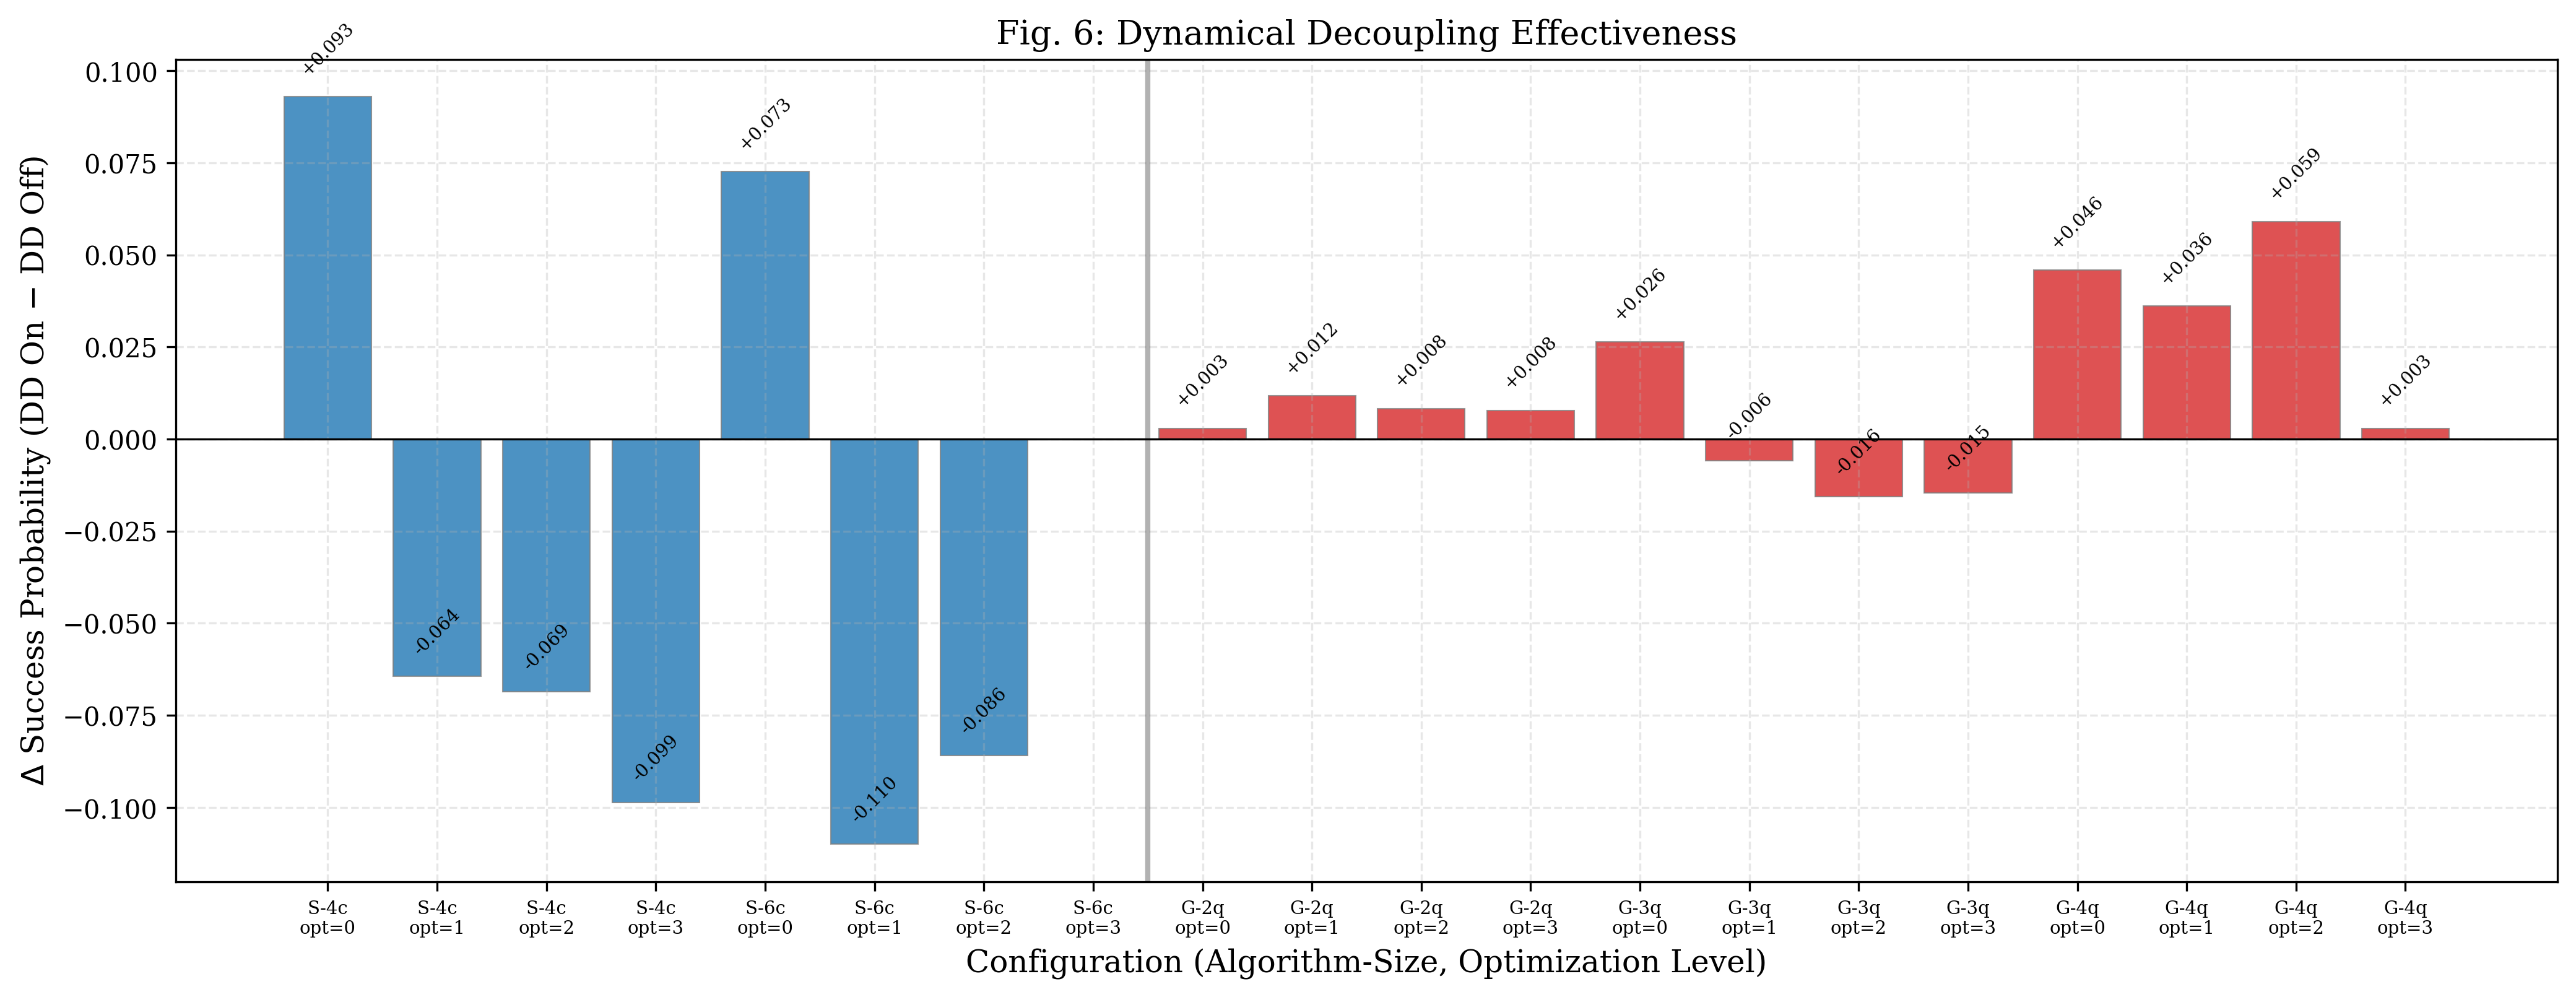

Saved: results/thesis_plots/dd_effectiveness.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 5.5))
bar_data = []

for df_csv, algo, size_key, color in [
    (shor, 'Shor', 'circuit_size', C_SHOR_HW),
    (grover, 'Grover', 'circuit_size', C_GROVER_HW),
]:
    for sz in sorted(df_csv[size_key].unique()):
        for opt in sorted(df_csv['opt_level'].unique()):
            sub = df_csv[(df_csv[size_key] == sz) & (df_csv['opt_level'] == opt)]
            dd_on = sub[sub['dd_enable'] == True]['hw_success_prob'].mean()
            dd_off = sub[sub['dd_enable'] == False]['hw_success_prob'].mean()
            label = f'S-{int(sz)}c' if algo == 'Shor' else f'G-{int(sz)}q'
            bar_data.append({'label': f'{label}\nopt={opt}', 'delta': dd_on - dd_off,
                            'algo': algo, 'color': color})

labels = [b['label'] for b in bar_data]
deltas = [b['delta'] for b in bar_data]
colors = [b['color'] for b in bar_data]

x = np.arange(len(labels))
bars = ax.bar(x, deltas, color=colors, alpha=0.8, edgecolor='gray', linewidth=0.5)

for bar, d in zip(bars, deltas):
    sign = '+' if d >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{sign}{d:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

n_shor = sum(1 for b in bar_data if b['algo'] == 'Shor')
ax.axvline(x=n_shor - 0.5, color='black', linestyle='-', alpha=0.3, linewidth=2)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Configuration (Algorithm-Size, Optimization Level)')
ax.set_ylabel('$\\Delta$ Success Probability (DD On $-$ DD Off)')
ax.set_title('Fig. 6: Dynamical Decoupling Effectiveness')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'dd_effectiveness.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Fig. 7: Fidelity Decay with Exponential Fit

  Shor decay fit: lambda=0.00330 +/- 0.00020, A=1.340, R^2=0.6049
  Grover decay fit: lambda=0.00478 +/- 0.00020, A=0.933, R^2=0.9461


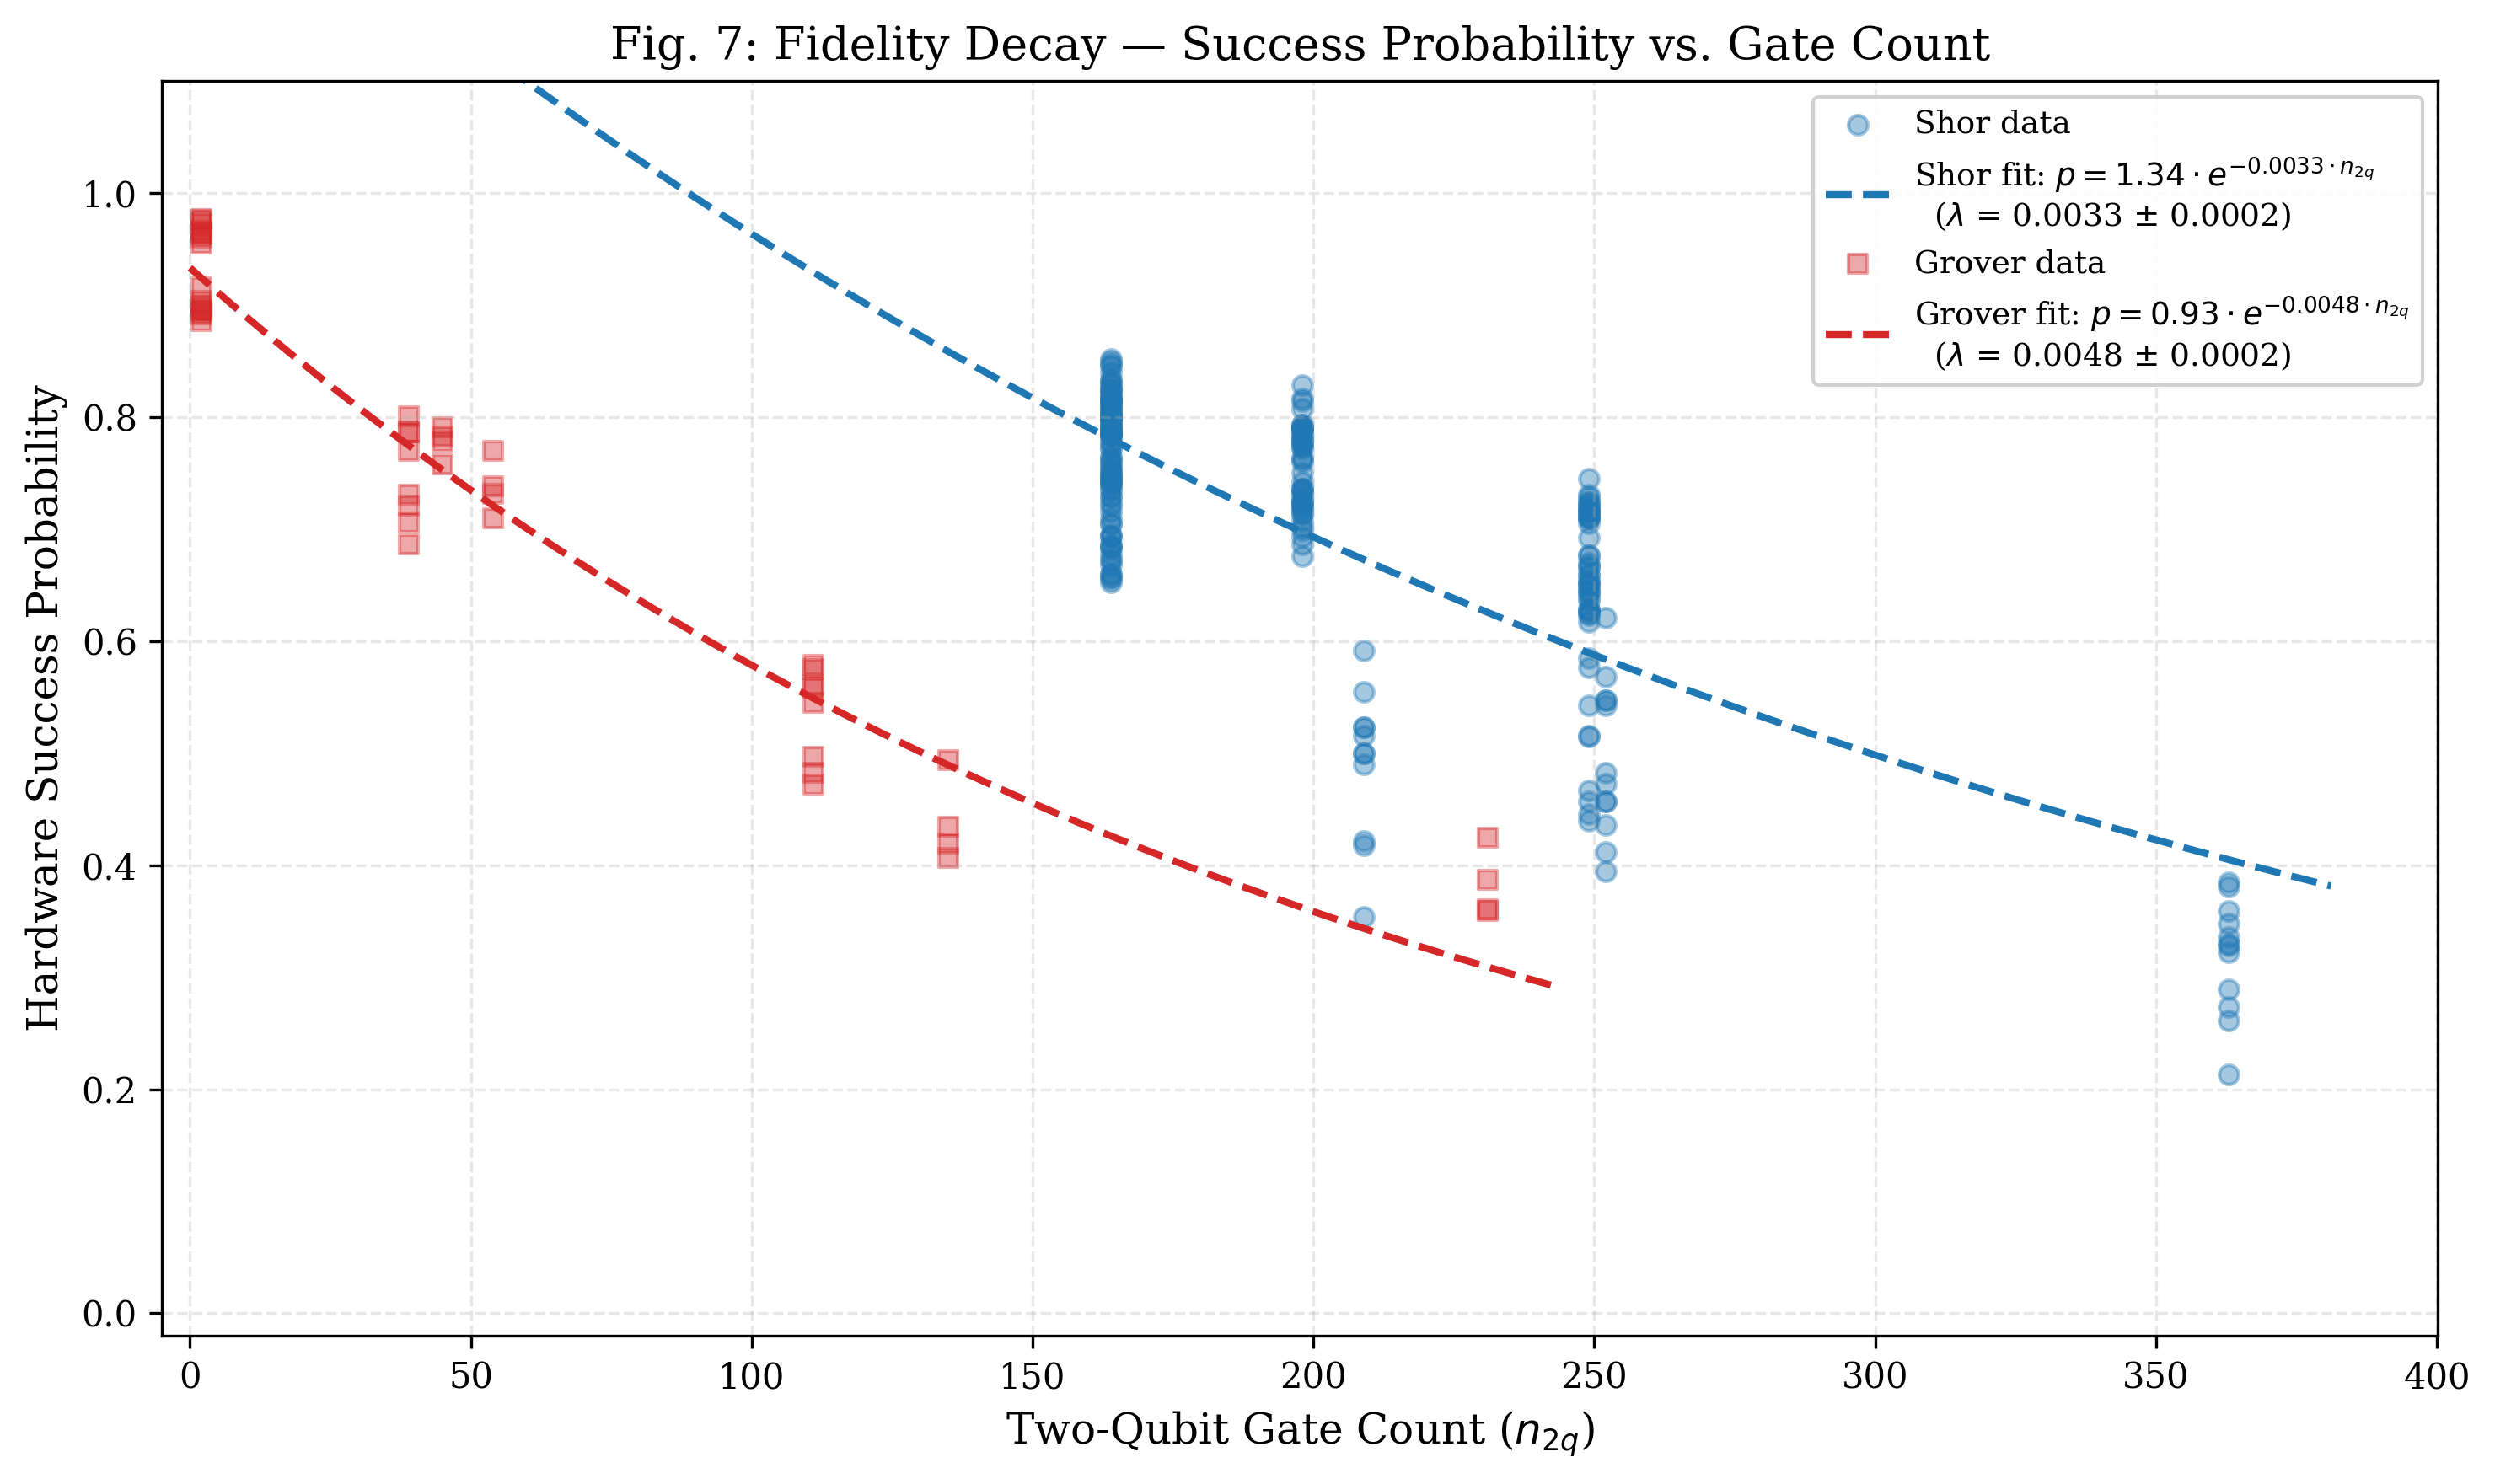

Saved: results/thesis_plots/fidelity_decay.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

def exp_decay(x, A, lam):
    return A * np.exp(-lam * x)

for df_csv, algo, color, marker in [
    (shor, 'Shor', C_SHOR_HW, 'o'),
    (grover, 'Grover', C_GROVER_HW, 's'),
]:
    counts = df_csv['count_2q'].values.astype(float)
    probs = df_csv['hw_success_prob'].values.astype(float)
    ax.scatter(counts, probs, c=color, marker=marker, alpha=0.4, s=30, label=f'{algo} data')

    valid = (probs > 0) & (counts > 0)
    if valid.sum() >= 3:
        try:
            popt, pcov = curve_fit(exp_decay, counts[valid], probs[valid],
                                   p0=[1.0, 0.005], maxfev=5000, bounds=([0, 0], [2.0, 1.0]))
            A_fit, lam_fit = popt
            perr = np.sqrt(np.diag(pcov))
            x_fit = np.linspace(0, counts.max() * 1.05, 200)
            y_fit = exp_decay(x_fit, A_fit, lam_fit)
            ax.plot(x_fit, y_fit, color=color, linewidth=2, linestyle='--',
                    label=f'{algo} fit: $p = {A_fit:.2f} \\cdot e^{{-{lam_fit:.4f} \\cdot n_{{2q}}}}$'
                          f'\n  ($\\lambda$ = {lam_fit:.4f} $\\pm$ {perr[1]:.4f})')
            ss_res = np.sum((probs[valid] - exp_decay(counts[valid], *popt))**2)
            ss_tot = np.sum((probs[valid] - probs[valid].mean())**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            print(f'  {algo} decay fit: lambda={lam_fit:.5f} +/- {perr[1]:.5f}, A={A_fit:.3f}, R^2={r2:.4f}')
        except RuntimeError:
            print(f'  {algo}: exponential fit did not converge')

ax.set_xlabel('Two-Qubit Gate Count ($n_{2q}$)')
ax.set_ylabel('Hardware Success Probability')
ax.set_title('Fig. 7: Fidelity Decay — Success Probability vs. Gate Count')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_ylim(-0.02, 1.1)
ax.set_xlim(-5, None)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'fidelity_decay.png')
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')


## Export Information-Theoretic Metrics

In [15]:
shor_info.to_csv(os.path.join(OUTPUT_DIR, 'shor_info_metrics.csv'), index=False)
grover_info.to_csv(os.path.join(OUTPUT_DIR, 'grover_info_metrics.csv'), index=False)
print(f'Saved: {os.path.join(OUTPUT_DIR, "shor_info_metrics.csv")}')
print(f'Saved: {os.path.join(OUTPUT_DIR, "grover_info_metrics.csv")}')
print(f'\nAll 7 figures saved to {os.path.abspath(OUTPUT_DIR)}/')


Saved: results/thesis_plots/shor_info_metrics.csv
Saved: results/thesis_plots/grover_info_metrics.csv

All 7 figures saved to /Users/destroy/Documents/GitHub/autoQiskit/src/results/thesis_plots/
